YOLOV8N-SEG

Скачиваем данные

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00


In [ ]:
!cp -r "/content/drive/MyDrive/CarDD_COCO" /content/

In [ ]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir="/content/CarDD_COCO/annotations/",
    save_dir="/content/CarDD_COCO/",
    use_segments=True,
    cls91to80=False
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Annotations /content/CarDD_COCO/annotations/instances_test2017.json: 100% ━━━━━━━━━━━━ 374/374 4.9Kit/s 0.1s
Annotations /content/CarDD_COCO/annotations/instances_train2017.json: 100% ━━━━━━━━━━━━ 2816/2816 4.6Kit/s 0.6s
Annotations /content/CarDD_COCO/annotations/instances_val2017.json: 100% ━━━━━━━━━━━━ 810/810 4.3Kit/s 0.2s
COCO data converted successfully.
Results saved to /content/CarDD_COCO-2


Создаем правильную структуру данных, которую трубует yolo

In [ ]:
!cp -r /content/CarDD_COCO/train2017 /content/CarDD_COCO-2/
!cp -r /content/CarDD_COCO/val2017 /content/CarDD_COCO-2/
!cp -r /content/CarDD_COCO/test2017 /content/CarDD_COCO-2/

In [ ]:
!mkdir -p /content/CarDD_YOLO-2/images/train
!mkdir -p /content/CarDD_YOLO-2/images/val
!mkdir -p /content/CarDD_YOLO-2/images/test
!mkdir -p /content/CarDD_YOLO-2/labels/train
!mkdir -p /content/CarDD_YOLO-2/labels/val
!mkdir -p /content/CarDD_YOLO-2/labels/test


!cp -r /content/CarDD_COCO-2/train2017/* /content/CarDD_YOLO-2/images/train/
!cp -r /content/CarDD_COCO-2/val2017/* /content/CarDD_YOLO-2/images/val/
!cp -r /content/CarDD_COCO-2/test2017/* /content/CarDD_YOLO-2/images/test/


!cp -r /content/CarDD_COCO-2/labels/train2017/* /content/CarDD_YOLO-2/labels/train/
!cp -r /content/CarDD_COCO-2/labels/val2017/* /content/CarDD_YOLO-2/labels/val/
!cp -r /content/CarDD_COCO-2/labels/test2017/* /content/CarDD_YOLO-2/labels/test/


yaml_content = """
path: /content/CarDD_YOLO-2
train: images/train
val: images/val
test: images/test

nc: 6
names: ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']
"""

with open('/content/CarDD_YOLO-2/dataset.yaml', 'w') as f:
    f.write(yaml_content)


In [ ]:
!ls /content/CarDD_YOLO-2

dataset.yaml  images  labels


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Обучаем модель (пока что с рандомным набором гиперпараметров)

In [ ]:
model = YOLO("yolov8n-seg.pt")

model.train(
    data='/content/CarDD_YOLO-2/dataset.yaml',
    epochs=30,
    batch=8,
    imgsz=768,
    device='cuda',
    workers=0,
    lr0=0.01,
    optimizer='SGD',
    weight_decay=0.0005,
    patience=20,
    seed=42,
    verbose=True,
    save=True,
    project='results',
    name='yolov8n_car_damage',
    degrees=45,
    mixup=0.5
)

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=45, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.5, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_car_damage, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=Tru

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e395ec2330>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004

In [ ]:
from google.colab import files
!zip -r /content/my_results3.zip /content/runs
files.download('/content/my_results3.zip')

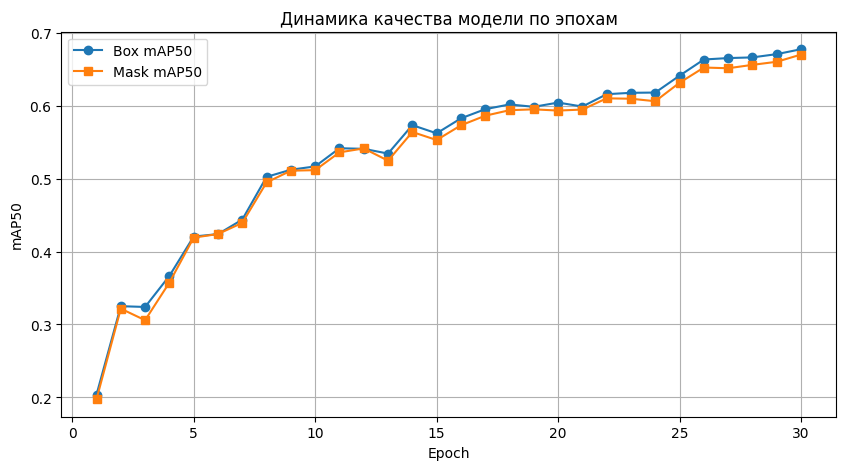

In [ ]:
results = pd.read_csv('/content/results.csv')
results = results.dropna(axis=1, how='all')


plt.figure(figsize=(10, 5))
plt.plot(results['epoch'], results['metrics/mAP50(B)'], label='Box mAP50', marker='o')
plt.plot(results['epoch'], results['metrics/mAP50(M)'], label='Mask mAP50', marker='s')
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.title('Динамика качества модели по эпохам')
plt.legend()
plt.grid(True)
plt.show()

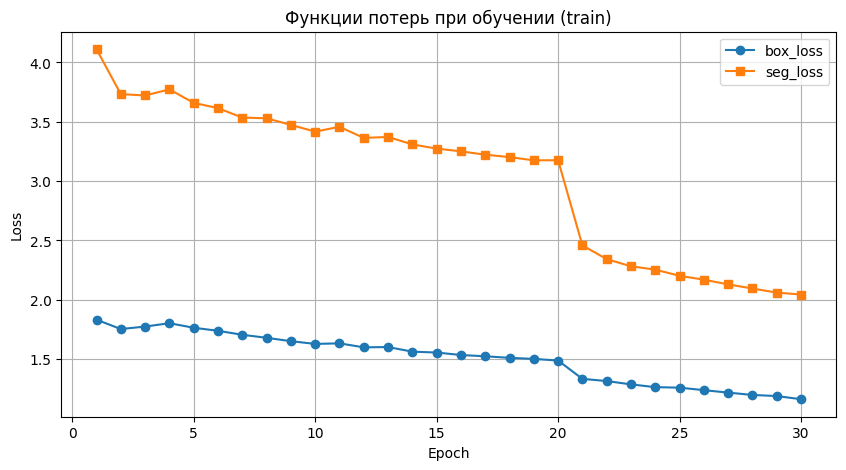

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(results['epoch'], results['train/box_loss'], label='box_loss', marker='o')
plt.plot(results['epoch'], results['train/seg_loss'], label='seg_loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функции потерь при обучении (train)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model = YOLO('/content/best.pt')


Found https://a.d-cd.net/4437558s-960.jpg locally at 4437558s-960.jpg
image 1/1 /content/4437558s-960.jpg: 448x768 1 lamp_broken, 10.3ms
Speed: 3.0ms preprocess, 10.3ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 768)


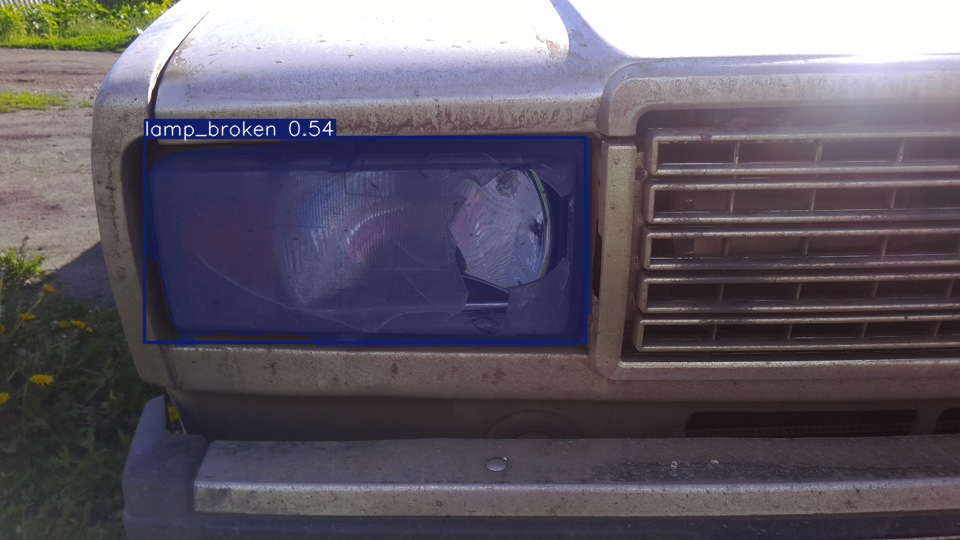


image 1/1 /content/360_F_258888084_suRecR9cLDLM2Cm6BS6Nrr6sc3on4yrm.jpg: 512x768 4 scratchs, 1 glass_shatter, 71.8ms
Speed: 4.2ms preprocess, 71.8ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 768)


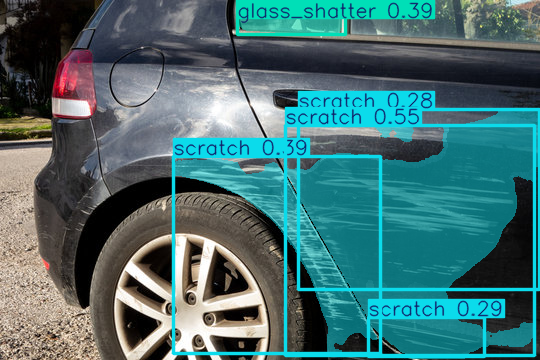


image 1/1 /content/360_F_318112625_kkVN3aTmO5KlzQumCyV7Zzcoe4JaW8T7.jpg: 512x768 3 scratchs, 10.4ms
Speed: 5.1ms preprocess, 10.4ms inference, 2.9ms postprocess per image at shape (1, 3, 512, 768)


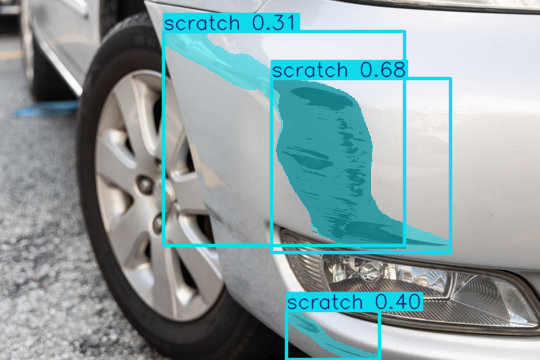


image 1/1 /content/0t9a1915-retouched-2048x1152.jpg: 448x768 (no detections), 11.0ms
Speed: 4.0ms preprocess, 11.0ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 768)


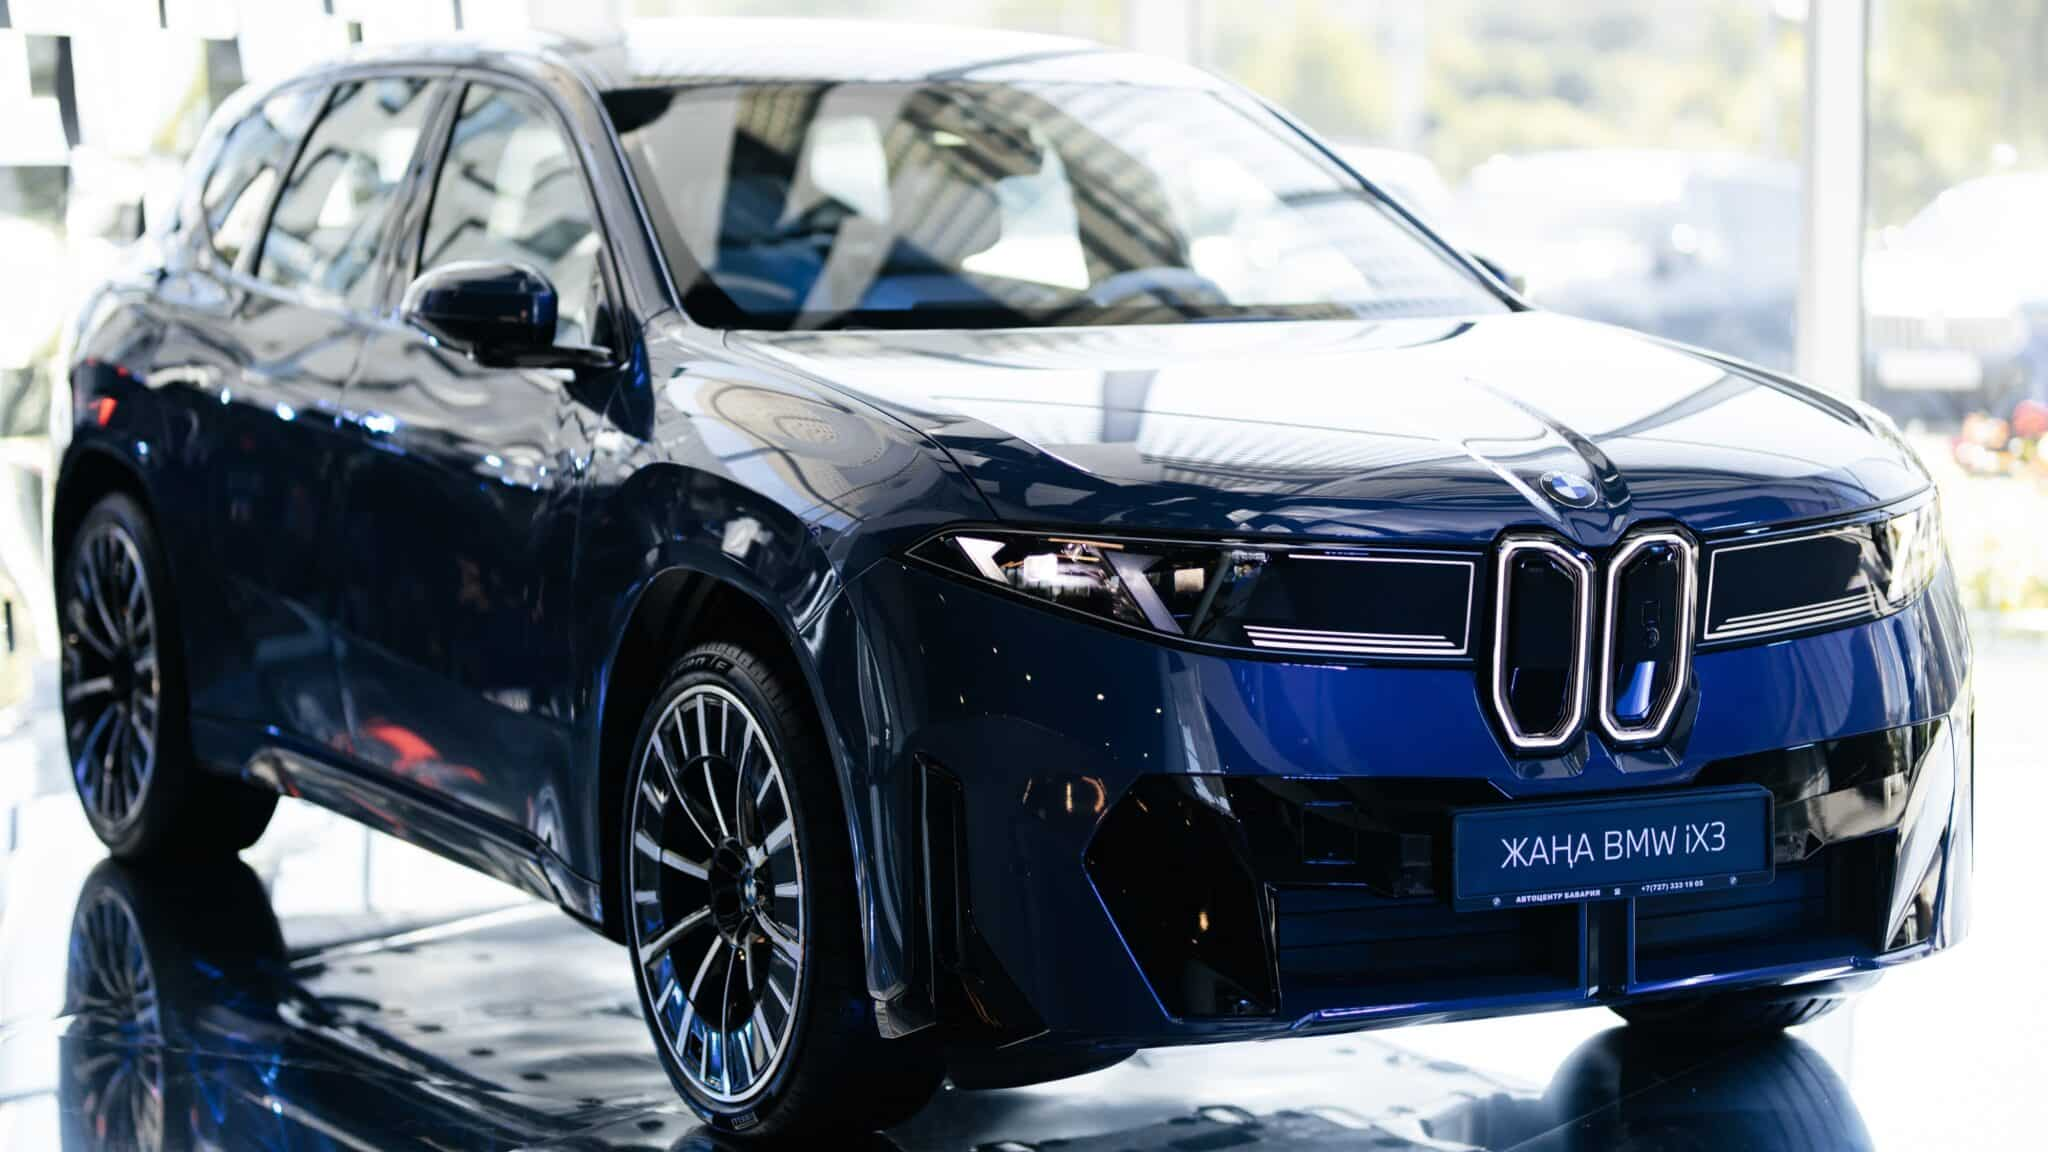

In [ ]:
test_images = ['https://a.d-cd.net/4437558s-960.jpg',
              'https://t3.ftcdn.net/jpg/02/58/88/80/360_F_258888084_suRecR9cLDLM2Cm6BS6Nrr6sc3on4yrm.jpg',
              'https://t3.ftcdn.net/jpg/03/18/11/26/360_F_318112625_kkVN3aTmO5KlzQumCyV7Zzcoe4JaW8T7.jpg',
              'https://cdn-kz.kursiv.media/wp-content/uploads/2026/06/0t9a1915-retouched-2048x1152.jpg']
for image in test_images:
  results = model(image)
  results[0].show()

Также хочется продемонстрировать как работала модель с другими параметрами

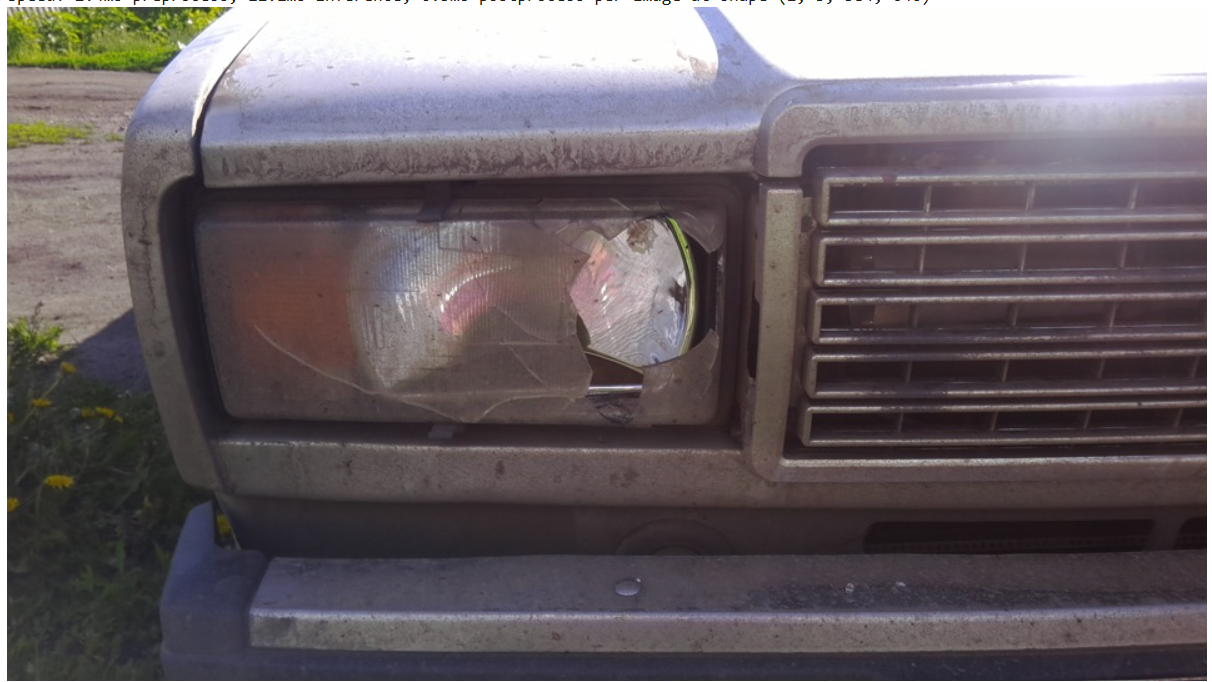

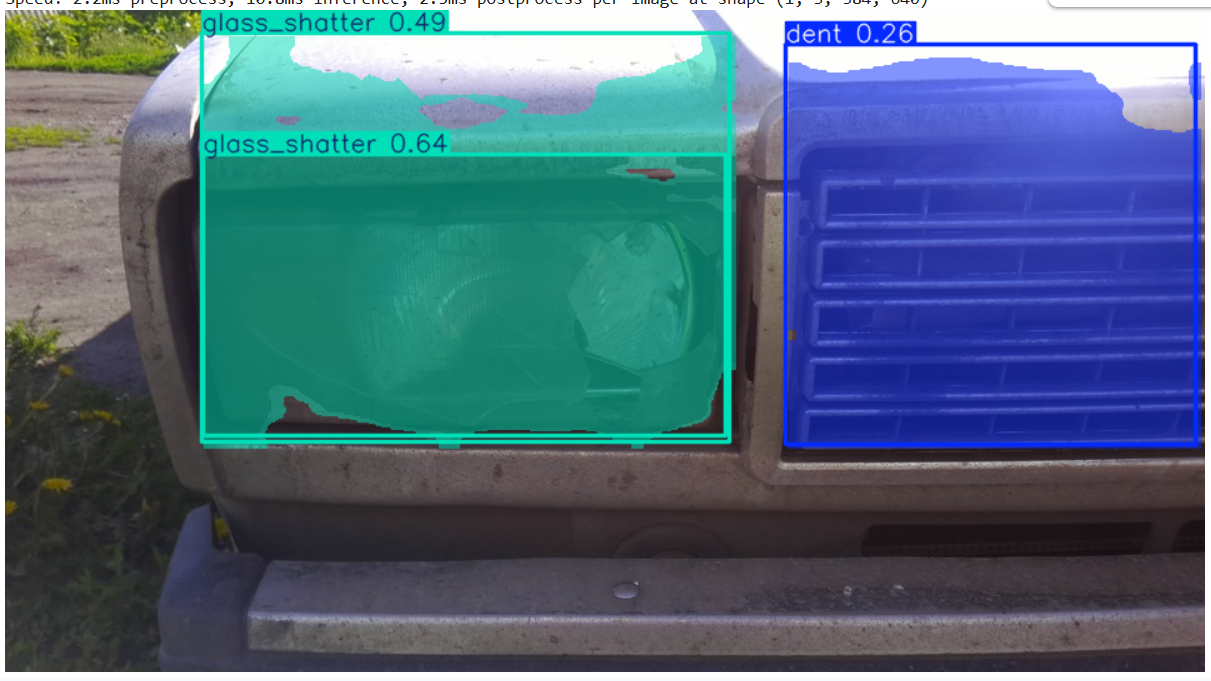